<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.875 · Deep Learning · PEC1</p>
<p style="margin: 0; text-align:right;">2025-2 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>


# PEC 1: Redes neuronales convolucionales con Keras y Pytorch - Clasificación de imágenes satelitales

A lo largo de esta práctica vamos a implementar varios modelos de redes neuronales para clasificar las imágenes de una base de datos de imágenes satelitales. Concretamente se desarrollaran las siguientes tareas:
1. Descarga, análisis y pre-procesado de los datos (1.5 pts)
2. Red neuronal completamente conectada (Dense NN) (1.5 pts)
3. Red convolucional (CNN) pequeña (2 pts)
4. Autoencoders (2 pts)
5. Transfer Learning con modelos eficientes: EfficientNetB0 (2 pts)
6. Introducción a Pytorch: Repllicando nuestra CNN (1 pt)

<u>Consideraciones generales</u>:

- La solución propuesta no debe utilizar métodos, funciones o parámetros declarados **_deprecated_** en versiones futuras.
- Esta PEC se debe hacer de manera **estrictamente individual**. Cualquier indicio de copia será penalizado con un suspenso (D) para todas las partes implicadas y la posible evaluación negativa de la totalidad de la asignatura.
- Es necesario que el estudiante indique **todas las fuentes** que ha utilizado para la realización de la PEC. En caso contrario, se considerará que el alumno ha cometido plagio, siendo penalizado con un suspenso (D) y la posible evaluación negativa de la totalidad de la asignatura.
- Si se utiliza cualquier **IA generativa** en la resolución del PAC **se debe referenciar** en aquellas secciones donde se ha utilizado, como cualquier otra fuente.

<u>Formato de la entrega</u>:

- Algunos ejercicios pueden suponer varios minutos de ejecución, de manera que la entrega se debe hacer en formato **Notebook** y en formato **html**, donde se vea el código, los resultados y los comentarios de cada ejercicio. Podéis exportar el cuaderno a HTML en Jupyter Notebook desde el menú File $\to$ Download as $\to$ HTML.
- Hay un tipo especial de celda para alojar el texto. Este tipo de celdas será muy útil para responder a las diferentes preguntas teóricas planteadas a lo largo de la actividad. Para cambiar el tipo de celda a este tipo, en el menú: Cell $\to$ Cell Type $\to$ Markdown.

<u>Dataset utilizado</u>:

En este PAC utilizaremos **UC Merced Land Use Dataset**, un conjunto de datos de libre acceso que consta de imágenes aéreas de alta resolución (2 m) de una región agrícola en el Valle Central de California.

## 0. Contexto y carga de librerías
Las imágenes tomadas por satélite son clave en la supervisión del uso y la cobertura del suelo, cuestiones relevantes para la gestión ambiental, la planificación urbana, la sostenibilidad y para combatir el cambio climático.

En esta práctica, trabajaremos con la base de datos [UC Merced Land Use Data](https://www.kaggle.com/datasets/zeadomar/uc-mercedland), que consiste en imágenes satelitales de 256x256 píxeles de 21 escenas diferentes: las clases son diversas, y contienen escenas e imágenes de aviones o ríos, entre otras categorías.

Concretamente trabajaremos con una versión aumentada de dicha base de datos que está disponible en un [repositorio de Kaggle](https://www.kaggle.com/datasets/apollo2506/landuse-scene-classification). En esta versión se han llevado a cabo varios procesos de aumentación de datos de tal forma que el número de imágenes por clase pasa de 100 a 500.

**Nota: Se recomienda realizar la práctica en el entorno que ofrece la plataforma Kaggle, ya que ofrece un entorno gratuito con 30 horas semanales de uso de GPU.**

A lo largo de toda la práctica, para la creación de las distintas redes, iremos alternando el uso del modelo [Sequential](https://keras.io/guides/sequential_model/) y el modelo [Functional](https://keras.io/guides/functional_api/) de Keras a través de las clases [Sequential](https://keras.io/api/models/sequential/) y [Model](https://keras.io/api/models/model/) respectivamente.

Empezamos cargando las librerías mas relevantes:

In [ ]:
# Importamos tensorflow
import tensorflow as tf
print("TF version   : ", tf.__version__)

# Necesitaremos GPU
print("GPU available: ", tf.config.list_physical_devices('GPU'))

# Importamos keras
import keras
print("Keras version   : ", keras.__version__)

2026-02-23 13:52:40.674158: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771854760.852338      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771854760.908471      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771854761.328331      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771854761.328397      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771854761.328403      55 computation_placer.cc:177] computation placer alr

TF version   :  2.19.0
GPU available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Keras version   :  3.10.0


In [ ]:
# Importamos los elementos de keras que utilizaremos con mayor frecuencia
from keras.utils import image_dataset_from_directory
from keras.layers import (
    GlobalAveragePooling2D, Flatten,
    Dense, Dropout, Conv2D, Conv2DTranspose, BatchNormalization,
    MaxPooling2D, UpSampling2D, Rescaling, Resizing)
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from keras import Sequential, Model

In [ ]:
# Importamos el resto de librerías que necesitaremos para la PEC
import cv2
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

## 1. Descarga, análisis y pre-procesado de los datos (1,5 puntos)

En este apartado exploraremos la base de datos y prepararemos la carga de las imágenes para los modelos de los siguientes apartados.

Para la descarga de la base de datos tenemos 2 opciones dependiendo de si decidimos trabajar en local o desde el entorno de Kaggle:
- Si trabajamos en local debemos descargar la base de datos desde el siguiente [enlace](https://www.kaggle.com/datasets/apollo2506/landuse-scene-classification/download?datasetVersionNumber=3) (es un archivo .zip que ocupa 2 GB) y descomprimirlo.
- Si trabajamos desde Kaggle. Debemos subir el Notebook del enunciado a la plataforma (para ello podéis seguir los 6 primeros pasos del siguiente [artículo](https://rajputankit22.medium.com/how-to-upload-my-own-notebook-to-kaggle-2b0dedbb5a6b)) y después, una vez subido el notebook, en la pestaña 'Input', clickar el botón '+ Add Input' y en la caja de búsqueda introducir la dirección 'https://www.kaggle.com/datasets/apollo2506/landuse-scene-classification'. Una vez encontrado el dataset darle al botón '+' (Add Dataset), y desde ese momento ya tendréis accesible la base de datos.

Una vez tenemos la base de datos accesible vamos a inspeccionarla.

Las imágenes se encuentran agrupadas de 2 formas diferentes:
- En la carpeta <code>/landuse-scene-classification/images/</code> se encuentra el total de las imágenes separadas por clases (cada clase en una carpeta distinta). Pero no se ha realizado una separación en conjunto de entrenamiento y test (o entrenamiento, validación y test).
- En la carpeta <code>/landuse-scene-classification/images_train_test_val/</code> se encuentran 3 carpetas (<code>test</code>, <code>train</code> y <code>validation</code>) en las que el total de imágenes se ha separado de forma aleatoria. En cada una de las 3 carpetas, tenemos imágenes de las 21 clases agrupadas en sus correspondientes carpetas. En la carpeta raíz <code>/landuse-scene-classification/</code> tenemos 3 archivos .csv con la distribución de cada carpeta.

En esta práctica utilizaremos el dataset ya particionado, es decir, trabajaremos con las imágenes que se encuentran en la ruta <code>/landuse-scene-classification/images_train_test_val/</code>.

### 1.1. Análisis de los archivos .csv

A partir de los archivos .csv podemos ver cómo se han distribuído los datos. Por ejemplo:

In [ ]:
train = pd.read_csv('/kaggle/input/datasets/apollo2506/landuse-scene-classification/train.csv')
train.head(5)

,Unnamed: 0,Filename,Label,ClassName
0,5818,runway/runway_000259.png,16,runway
1,1327,intersection/intersection_000348.png,10,intersection
2,2529,agricultural/agricultural_000025.png,0,agricultural
3,3865,chaparral/chaparral_000195.png,5,chaparral
4,2024,airplane/airplane_000260.png,1,airplane


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio [0,5 pts.]:</strong> A partir de los 3 archivos .csv se pide:
    <ul>
        <li>Extraer los nombres de las 21 clases (esto sólo hace falta hacerlo en uno de los 3 archivos)</li>
        <li>¿Cuántas instancias tenemos en total para cada conjunto de datos?</li>
        <li>Comprobar que las clases están balanceadas en los 3 conjuntos de datos (contando para cada conjunto, cuantas instancias/ejemplos tenemos para cada clase)</li>
    </ul>        
</div>

In [ ]:
# Extraer nombres de las clases
class_names = train['ClassName'].unique()
print('Las nombres de las clases son:')
for name in class_names:
    print(name)

Las nombres de las clases son:
runway
intersection
agricultural
chaparral
airplane
storagetanks
tenniscourt
overpass
harbor
buildings
mediumresidential
baseballdiamond
golfcourse
freeway
sparseresidential
river
mobilehomepark
forest
beach
parkinglot
denseresidential


In [ ]:
# Número de instancias por conjunto
val = pd.read_csv('/kaggle/input/datasets/apollo2506/landuse-scene-classification/validation.csv')
test = pd.read_csv('/kaggle/input/datasets/apollo2506/landuse-scene-classification/test.csv')

print('Número de instancias para entrenamiento = {}'.format(train.shape[0]))
print('Número de instancias para validación = {}'.format(val.shape[0]))
print('Número de instancias para test = {}'.format(test.shape[0]))

Número de instancias para entrenamiento = 7350
Número de instancias para validación = 2100
Número de instancias para test = 1050


In [ ]:
# Número de instancias por clase
print('Para el conjunto de datos de entrenamiento tenemos:')
train.groupby('ClassName').size()

Para el conjunto de datos de entrenamiento tenemos:


ClassName
agricultural         350
airplane             350
baseballdiamond      350
beach                350
buildings            350
chaparral            350
denseresidential     350
forest               350
freeway              350
golfcourse           350
harbor               350
intersection         350
mediumresidential    350
mobilehomepark       350
overpass             350
parkinglot           350
river                350
runway               350
sparseresidential    350
storagetanks         350
tenniscourt          350
dtype: int64

In [ ]:
print('Para el conjunto de datos de validación tenemos:')
val.groupby('ClassName').size()

Para el conjunto de datos de validación tenemos:


ClassName
agricultural         100
airplane             100
baseballdiamond      100
beach                100
buildings            100
chaparral            100
denseresidential     100
forest               100
freeway              100
golfcourse           100
harbor               100
intersection         100
mediumresidential    100
mobilehomepark       100
overpass             100
parkinglot           100
river                100
runway               100
sparseresidential    100
storagetanks         100
tenniscourt          100
dtype: int64

In [ ]:
print('Para el conjunto de datos de test tenemos:')
test.groupby('ClassName').size()

Para el conjunto de datos de test tenemos:


ClassName
agricultural         50
airplane             50
baseballdiamond      50
beach                50
buildings            50
chaparral            50
denseresidential     50
forest               50
freeway              50
golfcourse           50
harbor               50
intersection         50
mediumresidential    50
mobilehomepark       50
overpass             50
parkinglot           50
river                50
runway               50
sparseresidential    50
storagetanks         50
tenniscourt          50
dtype: int64

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentarios:</strong>
<br><br>
Como podemos ver, la base de datos está perfectamente balanceada puesto que tiene el mismo número de instancias para cada clase en cada uno de los conjuntos:
    <ul>
        <li> El conjunto de entrenamiento dispone de 7350 instancias (350 para cada clase)</li>
        <li> El conjunto de validación dispone de 2100 instancias (100 para cada clase)</li>
        <li> El conjunto de tests dispone de 1050 instancias (50 para cada clase)</li>
    </ul>
</div>

### 1.2. Análisis de las carpetas de imágenes.

Aunque se supone que cada archivo .csv refleja a la perfección el contenido de cada conjunto de datos, no está demás cerciorarse que el contenido del mismo se corresponde con lo anotado en cada archivo. Para ello se pide:

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio[0,5 pts]:</strong> Proporciona, a partir de las carpetas de imágenes, el número de imágenes que tenemos en cada categoría para cada conjunto de datos, comprobando que coincide con lo estipulado en el archivo .csv, y visualiza a modo de ejemplo una imagen por cada categoría. ¿Qué rango dinámico (valores mínimo y máximo) tienen las imágenes?
</div>

Category -- Number of Images
airplane	350
tenniscourt	350
river	350
denseresidential	350
parkinglot	350
storagetanks	350
overpass	350
sparseresidential	350
mediumresidential	350
intersection	350
baseballdiamond	350
runway	350
chaparral	350
freeway	350
beach	350
buildings	350
harbor	350
mobilehomepark	350
forest	350
golfcourse	350
agricultural	350

Random visualization


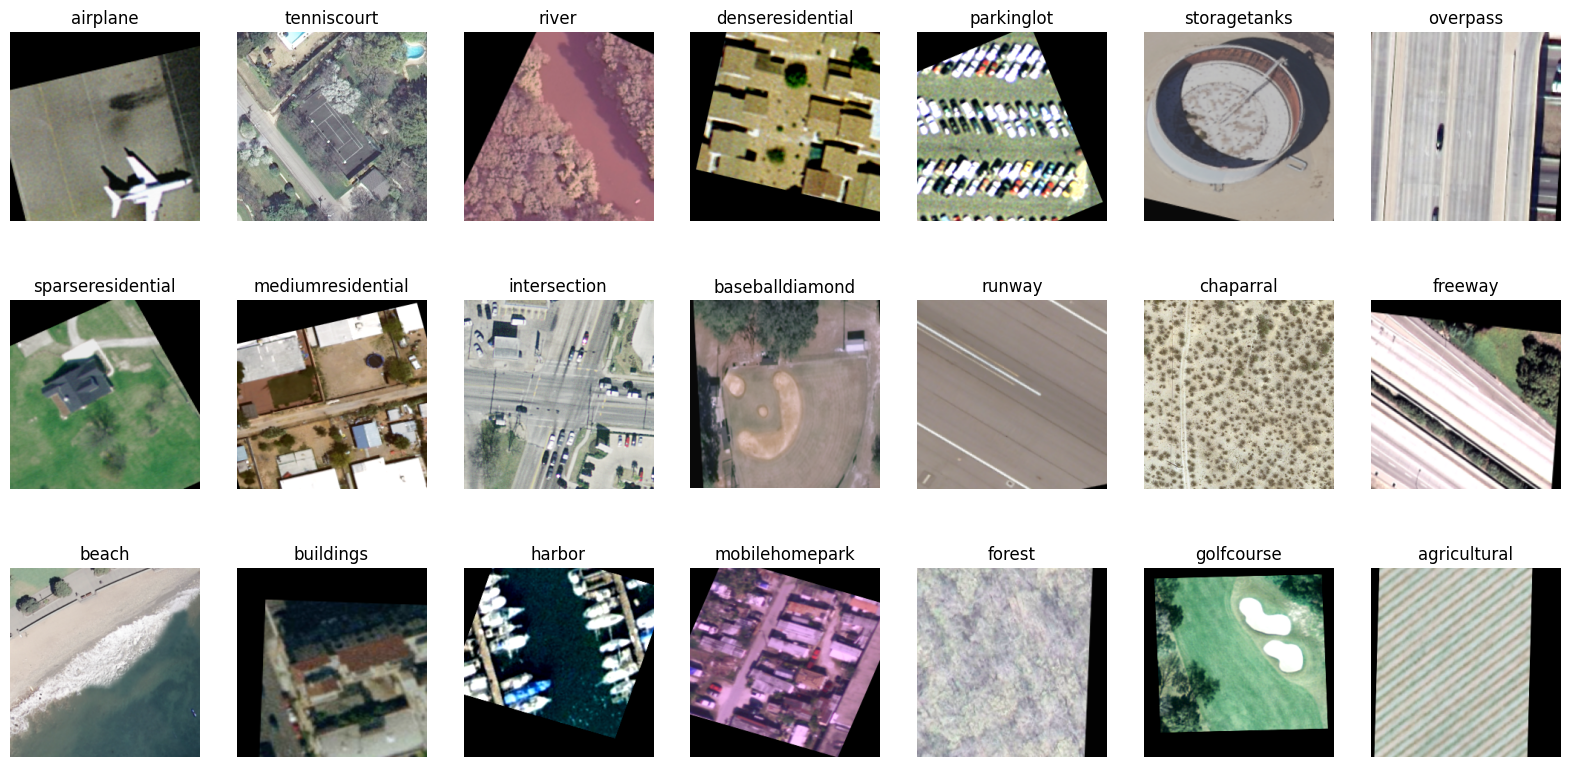

Dinamic range 0 226 uint8


In [ ]:
# Para el conjunto de datos de entrenamiento
path_data = "/kaggle/input/datasets/apollo2506/landuse-scene-classification/images_train_test_val/train"
list_images = glob.glob(os.path.join(path_data, "*/*.png"))
categories = os.listdir(path_data)

plt.figure(figsize=(20,20))
plt.subplots_adjust(bottom=0.5)

print("=============================")
print("Category -- Number of Images")
print("=============================")
for i, c in enumerate(categories):
    selected = [filename for filename in list_images if c in filename]
    np.random.shuffle(selected)
    print("{}\t{}".format(c,len(selected)))

    img = cv2.imread(selected[0])
    plt.subplot(3,7, 1+i), plt.imshow(img[:,:,::-1])
    plt.title(c)
    plt.axis('off')

print()
print("=============================")
print("Random visualization")
print("=============================")
plt.show()

print("Dinamic range", img.min(), img.max(), img.dtype)

Category -- Number of Images
airplane	100
tenniscourt	100
river	100
denseresidential	100
parkinglot	100
storagetanks	100
overpass	100
sparseresidential	100
mediumresidential	100
intersection	100
baseballdiamond	100
runway	100
chaparral	100
freeway	100
beach	100
buildings	100
harbor	100
mobilehomepark	100
forest	100
golfcourse	100
agricultural	100

Random visualization


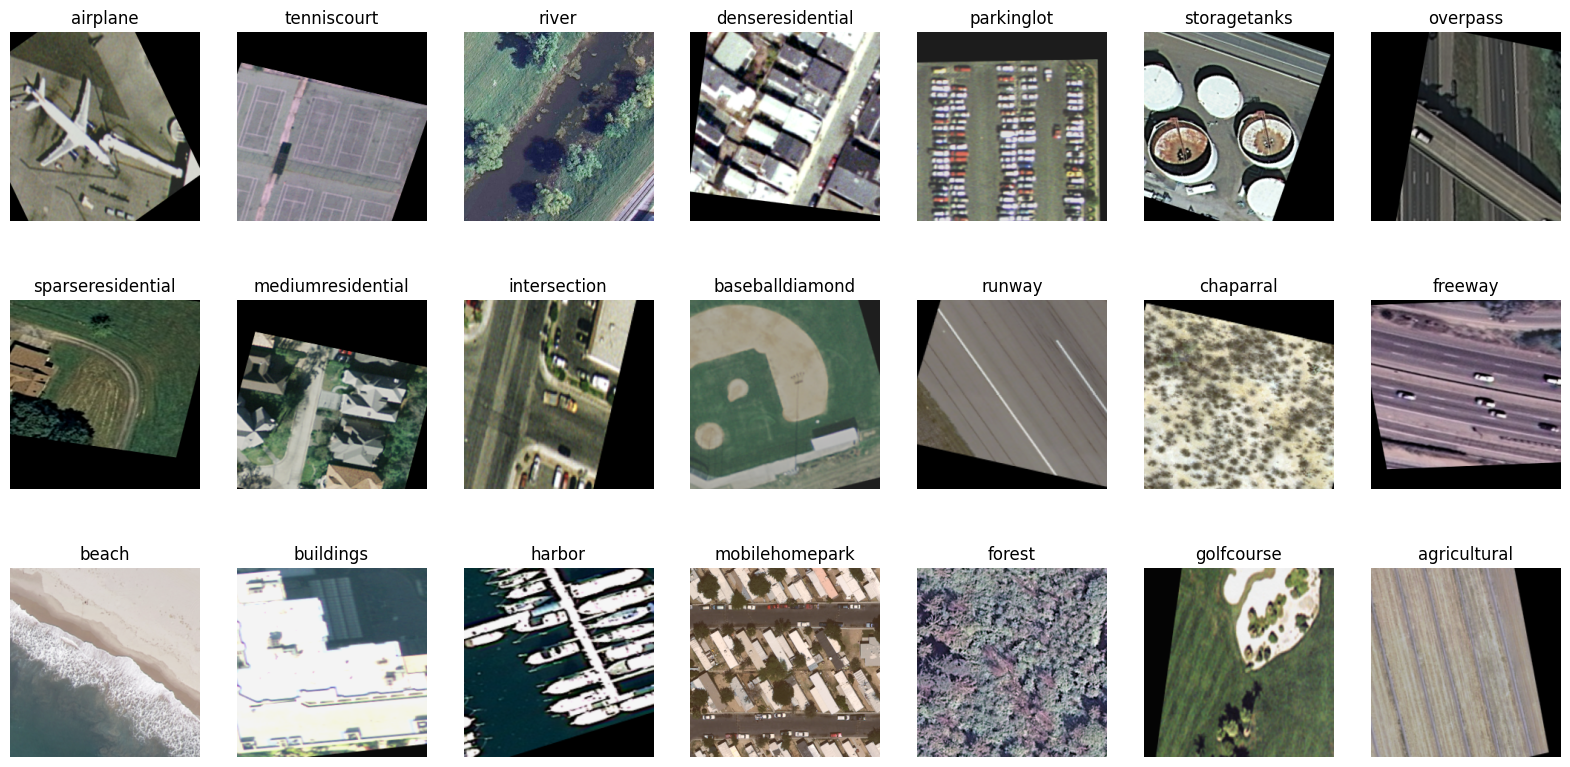

Dinamic range 0 200 uint8


In [ ]:
# Para el conjunto de datos de validación
path_data = "/kaggle/input/datasets/apollo2506/landuse-scene-classification/images_train_test_val/validation"
list_images = glob.glob(os.path.join(path_data, "*/*.png"))
categories = os.listdir(path_data)

plt.figure(figsize=(20,20))
plt.subplots_adjust(bottom=0.5)

print("=============================")
print("Category -- Number of Images")
print("=============================")
for i, c in enumerate(categories):
    selected = [filename for filename in list_images if c in filename]
    np.random.shuffle(selected)
    print("{}\t{}".format(c,len(selected)))

    img = cv2.imread(selected[0])
    plt.subplot(3,7, 1+i), plt.imshow(img[:,:,::-1])
    plt.title(c)
    plt.axis('off')

print()
print("=============================")
print("Random visualization")
print("=============================")
plt.show()

print("Dinamic range", img.min(), img.max(), img.dtype)

Category -- Number of Images
airplane	50
tenniscourt	50
river	50
denseresidential	50
parkinglot	50
storagetanks	50
overpass	50
sparseresidential	50
mediumresidential	50
intersection	50
baseballdiamond	50
runway	50
chaparral	50
freeway	50
beach	50
buildings	50
harbor	50
mobilehomepark	50
forest	50
golfcourse	50
agricultural	50

Random visualization


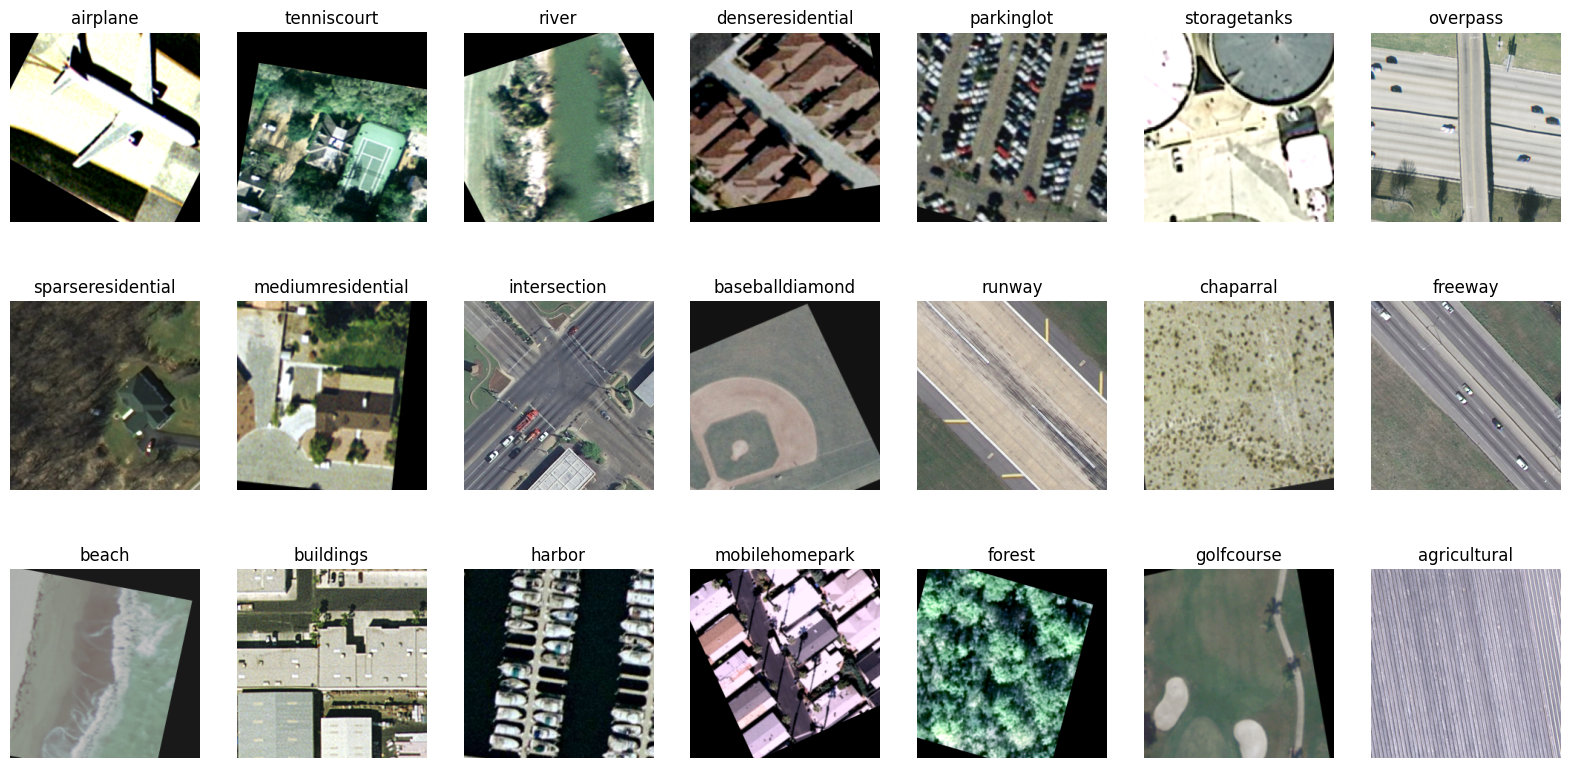

Dinamic range 97 255 uint8


In [ ]:
# Para el conjunto de datos de test
path_data = "/kaggle/input/datasets/apollo2506/landuse-scene-classification/images_train_test_val/test"
list_images = glob.glob(os.path.join(path_data, "*/*.png"))
categories = os.listdir(path_data)

plt.figure(figsize=(20,20))
plt.subplots_adjust(bottom=0.5)

print("=============================")
print("Category -- Number of Images")
print("=============================")
for i, c in enumerate(categories):
    selected = [filename for filename in list_images if c in filename]
    np.random.shuffle(selected)
    print("{}\t{}".format(c,len(selected)))

    img = cv2.imread(selected[0])
    plt.subplot(3,7, 1+i), plt.imshow(img[:,:,::-1])
    plt.title(c)
    plt.axis('off')

print()
print("=============================")
print("Random visualization")
print("=============================")
plt.show()

print("Dinamic range", img.min(), img.max(), img.dtype)

### 1.3. Creación de los conjuntos de datos en formato Keras/Tensorflow
​
Con el objetivo de crear una base de datos en el formato Keras/Tensorflow a partir de las imágenes proporcionadas utilizaremos la función <code>**tf.keras.utils.image_dataset_from_directory()**</code> ya que nos permite crear bases de datos a partir de imágenes guardadas en carpetas.

La documentación de esta función se encuentra tanto en la web de [Keras](https://keras.io/api/data_loading/image/) como en la de [Tensorflow](https://www.tensorflow.org/api_docs/python/tf/keras/utils/image_dataset_from_directory) .

Además, aprovecharemos para redimensionar las imágenes y pasarlas a tamaño 224x224, que es el tamaño con el que se ha entrenado la red EfficientNetB0 que utilizaremos en un apartado posterior.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio[0,5 pts]:</strong> Utiliza la función  <code>image_dataset_from_directory()</code> para generar 3 conjuntos de datos (<code>train_data</code>, <code>val_data</code> y <code>test_data</code>) a partir de las carpetas analizadas. Las imágenes deben ser redimensionadas a tamaño 224x224 píxels RGB (224,224,3) y agrupadas en lotes de tamaño 32 (batch=32) manteniendo su rango dinámico.
</div>

In [ ]:
train_dir = "/kaggle/input/datasets/apollo2506/landuse-scene-classification/images_train_test_val/train"
val_dir = "/kaggle/input/datasets/apollo2506/landuse-scene-classification/images_train_test_val/validation"
test_dir = "/kaggle/input/datasets/apollo2506/landuse-scene-classification/images_train_test_val/test"

In [ ]:
train_data = image_dataset_from_directory(train_dir,
                                         labels="inferred",
                                         label_mode="categorical",
                                         image_size=(224, 224))
val_data = image_dataset_from_directory(val_dir,
                                         labels="inferred",
                                         label_mode="categorical",
                                         image_size=(224, 224))
test_data = image_dataset_from_directory(test_dir,
                                         labels="inferred",
                                         label_mode="categorical",
                                         image_size=(224, 224))

Found 7350 files belonging to 21 classes.


I0000 00:00:1771854793.015335      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 2100 files belonging to 21 classes.
Found 1050 files belonging to 21 classes.


## 2. Red neuronal completamente conectada (Dense NN) (1,5 puntos)

En este apartado, vamos a entrenar y evaluar un modelo muy sencillo completamente conectado para establecer un resultado de referencia.

Dado que en una red neuronal artificial las entradas son unidimensionales, lo primero que tenemos que hacer es redimensionar los datos de entrada (las imágenes) para convertirlos en arrays de una dimensión.

Como trabajar con imágenes de tamaño 224x224 en una red completamente conectada implicaría entrenar un número de parámetros excesivamente elevado definiremos un modelo en el que se realizará previamente un redimensionado de las imágenes de entrada a un tamaño de 32x32 y un achatamiento (*flattening*) de los píxeles para así generar un vector unidimensional de tamaño 3072 (32x32x3).

Posteriormente entrenaremos un clasificador (una red completamente conectada) para llevar a cabo la clasificación de nuestros datos.

En este apartado utilizaremos las capas [Resizing](https://keras.io/api/layers/preprocessing_layers/image_preprocessing/resizing/), [Rescaling](https://keras.io/api/layers/preprocessing_layers/image_preprocessing/rescaling/), [Flatten](https://keras.io/api/layers/reshaping_layers/flatten/), [Dense](https://keras.io/api/layers/core_layers/dense/) y [Dropout](https://keras.io/api/layers/regularization_layers/dropout/) de keras.


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio:</strong> Implementa un modelo <strong>secuencial</strong> de Keras (a partir de la clase <code>Sequential()</code>) con las siguientes especificaciones:
    <ul>
        <li>Una capa que reduzca las dimensiones de entrada de (224,224) a (32,32)</li>
        <li>Una capa de reescalado para conseguir que los valores de la imagen estén entre 0 y 1</li>
        <li>Una capa Flatten para convertir la imagen en un vector de 3072 posiciones</li>
        <li>Una capa completamente conectada de 1024 neuronas y activación ReLU</li>
        <li>Una capa de Dropout (con probabilidad 0.5)</li>
        <li>Una capa de salida completamente conectada correspondiente a la clasificación final cuyo número de neuronas debe ser igual al múmero de clases de la base de datos y con la función de activación adecuada para llevar a cabo esta tarea de clasificación.</li>
    </ul>
        
Compilar y entrenar el modelo siguiendo las siguientes indicaciones:
     <ul>
         <li>Utilizar el optimizador Adam con  <i>learning rate</i> de 0.0001.</li>
         <li>Entrenar durante 100 épocas utilizando  <i>EarlyStopping</i> con una persistencia de 10 épocas, monitorizando la función de pérdida en el conjunto de validación, y guardando los pesos que mejor resultado hayan obtenido.</li>
         <li>Monitorizar la métrica  <i>accuracy</i> durante entrenamiento y validación.</li>
         <li>Mostrar las gráficas de accuracy y loss. En cada gráfica debe visualizarse la curva de entrenamiento y la de validación. NOTA: Se recomienda hacer una función que imprima ambas gráficas para poder reutilizarla en próximos apartados.</li>
         <li>Realizar la evaluación del modelo una vez ha finalizado el entrenamiento para mostrar la pérdida y la exactitud final sobre los datos de test.</li>
    </ul>
    Preguntas a responder: ¿Cúal es el número de parámetros a entrenar? ¿y el tiempo de entrenamiento? ¿Qué precisión se obtiene con este modelo? Comenta los resultados.<br/>    
    <strong> NOTA: se recomienda, al final de la creación de cada modelo, utilizar la función <code>summary()</code> para comprobar la estructura de la red creada, así como el numero de parámetros que se deben entrenar. Se recomienda hacerlo en todos los ejercicios.</strong>
</div>

In [ ]:
# Definición de la red
ann_model = Sequential()

ann_model.add(Resizing(32,32,input_shape=(224,224,3)))
ann_model.add(Rescaling(1./255))
ann_model.add(Flatten())
ann_model.add(Dense(1024, activation="relu"))
ann_model.add(Dropout(0.5))
ann_model.add(Dense(21, activation="softmax"))

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │        21,525 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,168,277 (12.09 MB)

 Trainable params: 3,168,277 (12.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compilación de la red
opt = Adam(learning_rate=0.0001)

ann_model.compile(
    optimizer=opt,
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

stopping =  EarlyStopping(monitor='val_loss',
                            patience=10,
                            verbose=1,
                            restore_best_weights=True)

In [ ]:
# Entrenamiento de la red
t = time.time()
ann_history = ann_model.fit(train_data,
                            epochs=100,
                            callbacks=[stopping],
                            verbose=1,
                            validation_data=val_data)
print ("Tiempo de entrenamiento: ",time.time() - t, "segundos.")

Epoch 1/100


I0000 00:00:1771854797.500129     130 service.cc:152] XLA service 0x79d1f4003d30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771854797.500190     130 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771854797.803858     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


  7/230 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.0355 - loss: 3.3997

I0000 00:00:1771854798.955450     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


230/230 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.0567 - loss: 3.2025 - val_accuracy: 0.0929 - val_loss: 3.0052
Epoch 2/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.0879 - loss: 2.9983 - val_accuracy: 0.1057 - val_loss: 2.9731
Epoch 3/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.1105 - loss: 2.9625 - val_accuracy: 0.1171 - val_loss: 2.9320
Epoch 4/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.1205 - loss: 2.9212 - val_accuracy: 0.1210 - val_loss: 2.9243
Epoch 5/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.1312 - loss: 2.8736 - val_accuracy: 0.1548 - val_loss: 2.8814
Epoch 6/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.1458 - loss: 2.8287 - val_accuracy: 0.1505 - val_loss: 2.8552
Epoch 7/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.1552 - loss: 2.8019 - val_accuracy: 0.1690 - val_loss: 2.8281
Epoch 8/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.1847 - loss: 2.7465 - val_

In [ ]:
# Plot del training loss y la accuracy
def plot_training(n_epochs, mfit):
    N = n_epochs
    plt.style.use("ggplot")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))
    fig.suptitle('Training Loss and Accuracy')

    ax1.plot(np.arange(0, N), mfit.history["accuracy"], label="train")
    ax1.plot(np.arange(0, N), mfit.history["val_accuracy"], label="val")
    ax1.set_title("Accuracy")
    ax1.set_xlabel("Epoch #")
    ax1.set_ylabel("Accuracy")
    ax1.legend(loc="lower right")

    ax2.plot(np.arange(0, N), mfit.history["loss"], label="train")
    ax2.plot(np.arange(0, N), mfit.history["val_loss"], label="val")
    ax2.set_title("Loss")
    ax2.set_xlabel("Epoch #")
    ax2.set_ylabel("Loss")
    ax2.legend(loc="upper right")

    plt.show()

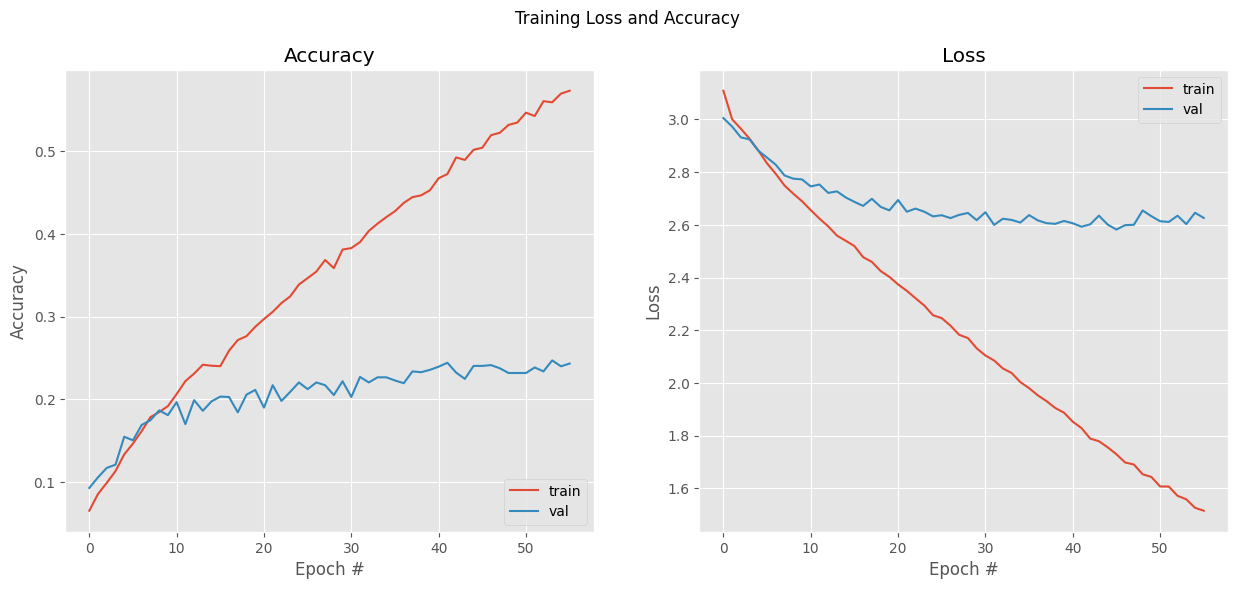

----------
Loss: 2.614822
Accuracy: 0.236190


In [ ]:
n_epochs = len(ann_history.history["loss"])
plot_training(n_epochs, ann_history)

score = ann_model.evaluate(test_data, verbose=0)
print ("-"*10)
print ("Loss: %f"%(score[0]))
print ("Accuracy: %f"%(score[1]))

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentarios:</strong>
<br><br>
Los resultados obtenidos son:
    <ul>
        <li> Número de parámetros a entrenar: 3,168,277</li>
        <li> Tiempo de entrenamiento: 635 segundos (finaliza en 57 épocas)</li>
        <li> Accuracy: 23.62 %</li>
    </ul>
Los resultados son muy pobres. El número de parámetros a entrenar es muy elevado comparado con las prestaciones obtenidas. Esto se debe a que el modelo completamente conectado no es capaz de extraer, a partir de los datos proporcionados, las características necesarias para realizar una clasificación correcta.
</div>

## 3. Red convolucional pequeña (2 puntos)

Dadas las bajas prestaciones del modelo anterior vamos a probar otro tipo de redes con el objetivo de obtener unos mejores resultados en la tarea de clasificación que debemos llevar a cabo.

Las redes convolucionales (CNN) son especialmente adecuadas para modelar datos donde hay patrones en 2 dimensiones, como es el caso de las imágenes.

En la tarea de clasificación, la estructura de una CNN se divide en dos grandes bloques:

* **Bloque extractor de características**: En este bloque se generan diferentes niveles de abstracción de la imagen de entrada mediante capas convolucionales. Cuanto más profundas son estas capas, más preparadas están para la tarea de clasificación.
* **Clasificador**: Este bloque está formado por capas totalmente conectadas, la salida de este bloque será la probabilidad asociada a cada clase.

En el apartado anterior, el bloque "extractor de características" era extremadamente simple, por no decir inexistente. En este apartado, vamos a hacer uso de capas convolucionales para poder aprender mejores abstracciones de las imágenes de entrada con el fin de mejorar su clasificación.

En este apartado utilizaremos las capas [Conv2D](https://keras.io/api/layers/convolution_layers/convolution2d/),  [MaxPooling2D](https://keras.io/api/layers/pooling_layers/max_pooling2d/), [GlobalAveragePooling2D](https://keras.io/api/layers/pooling_layers/global_average_pooling2d/), [Dense](https://keras.io/api/layers/core_layers/dense/) y [Dropout](https://keras.io/api/layers/regularization_layers/dropout/) de keras.

**Nota: Se recomienda, a partir de este punto realizar el entrenamiento en una máquina con GPU (puede activarse en plataformas como Google Colab o Kaggle) con el fin de reducir los tiempos de entrenamiento.**

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio [2 puntos]:</strong> A partir del modelo <strong>funcional</strong> de keras (y la clase <code>Model()</code>), implementa una red con las siguientes características:
    <ul>
        <li>Un bloque extractor de características que conste de:
            <ul>
                <li>Una capa de entrada de dimensiones adecuadas a los datos.</li>
                <li>Una capa de rescalado para conseguir que los valores de la imagen estén entre 0 y 1.</li>
                <li>3 capas convolucionales con tamaño de kernel (5x5) para la primera y (3x3) para las 2 siguientes. Se utilizará padding '<i>same</i>' y activación ReLU. El número de filtros para cada capa convolucional será 16, 32 y 64 respectivamente.</li>
                <li>A cada capa convolucional le sigue una capa de <i>Max Pooling</i></li>
                <li>Una capa de <i>average pooling</i> (GlobalAveragePooling2D) para reducir las dimensiones a un vector de 1024 dimensiones.</li>
            </ul></li>
        <li>El clasificador final sigue la estructura del modelo del apartado anterior:
            <ul>
                <li>Una capa completamente conectada de 1024 neuronas y activación ReLU</li>
                <li>Una capa de Dropout (con probabilidad 0.5)</li>
                <li>Una capa de salida completamente conectada correspondiente a la clasificación final cuyo número de neuronas debe ser igual al múmero de clases de la base de datos y con la función de activación adecuada para llevar a cabo esta tarea de clasificación.</li>
            </ul></li>
    </ul>
    
Compilar y entrenar el modelo siguiendo las siguientes indicaciones:
     <ul>
         <li>Utilizar el optimizador Adam con  <i>learning rate</i> de 0.001.</li>
          <li>Entrenar durante 100 épocas utilizando  <i>EarlyStopping</i> con una persistencia de 10 épocas, monitorizando la función de pérdida en el conjunto de validación, y guardando los pesos que mejor resultado hayan obtenido.</li>
         <li>Monitorizar la métrica  <i>accuracy</i> durante entrenamiento y validación.</li>
         <li>Mostrar las gráficas de <i>accuracy</i> y <i>loss</i>. En cada gráfica debe visualizarse la curva de entrenamiento y la de validación.</li>
         <li>Realizar la evaluación del modelo una vez ha finalizado el entrenamiento para mostrar la pérdida y la exactitud final sobre los datos de test.</li>
    </ul>
    Preguntas a responder: ¿Cúal es el número de parámetros a entrenar? ¿y el tiempo de entrenamiento? ¿Qué precisión se obtiene con este modelo? Comenta los resultados.
</div>

In [ ]:
# Definición de la red
# Feature extractor
input_layer = keras.Input(shape=(224, 224, 3), name="image")
x = Rescaling(1./255)(input_layer)
x = Conv2D(16, (5, 5), padding='same', activation="relu", name='conv1')(x)
x = MaxPooling2D()(x)
x = Conv2D(16*2, (3, 3), padding='same', activation="relu", name='conv2')(x)
x = MaxPooling2D()(x)
x = Conv2D(16*4, (3, 3), padding='same', activation="relu", name='conv3')(x)
x = MaxPooling2D((2,2))(x)
x = GlobalAveragePooling2D(name='average')(x)

# Classificator
x = Dense(1024, name='dense1', activation="relu")(x)
x = Dropout(0.5)(x)
x = Dense(21, name='classifier', activation="softmax")(x)


cnn_model = keras.Model(input_layer, x, name="model")
cnn_model.summary()

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 224, 224, 16)   │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average                         │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1024)           │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 21)             │        21,525 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,437 (439.21 KB)

 Trainable params: 112,437 (439.21 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compilación de la red
opt = Adam(learning_rate=0.001)

cnn_model.compile(
    optimizer=opt,
    loss="categorical_crossentropy",
    metrics=["accuracy"])

stopping =  EarlyStopping(monitor='val_loss',
                            patience=10,
                            verbose=1,
                            restore_best_weights=True)

In [ ]:
# Entrenamiento
t = time.time()
cnn_history = cnn_model.fit(train_data,
                            epochs=100,
                            callbacks=[stopping],
                            verbose=1,
                            validation_data=val_data)
print ("Tiempo de entrenamiento: ",time.time() - t, "segundos.")

Epoch 1/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.0706 - loss: 2.9764 - val_accuracy: 0.1510 - val_loss: 2.6649
Epoch 2/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.1705 - loss: 2.5651 - val_accuracy: 0.2348 - val_loss: 2.3268
Epoch 3/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.2589 - loss: 2.2715 - val_accuracy: 0.3219 - val_loss: 2.0681
Epoch 4/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.3306 - loss: 2.0415 - val_accuracy: 0.3695 - val_loss: 1.9429
Epoch 5/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.3741 - loss: 1.9040 - val_accuracy: 0.3748 - val_loss: 1.8795
Epoch 6/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.4172 - loss: 1.7637 - val_accuracy: 0.4371 - val_loss: 1.7188
Epoch 7/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.4474 - loss: 1.6583 - val_accuracy: 0.4524 - val_loss: 1.6304
Epoch 8/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.4711 - loss: 1

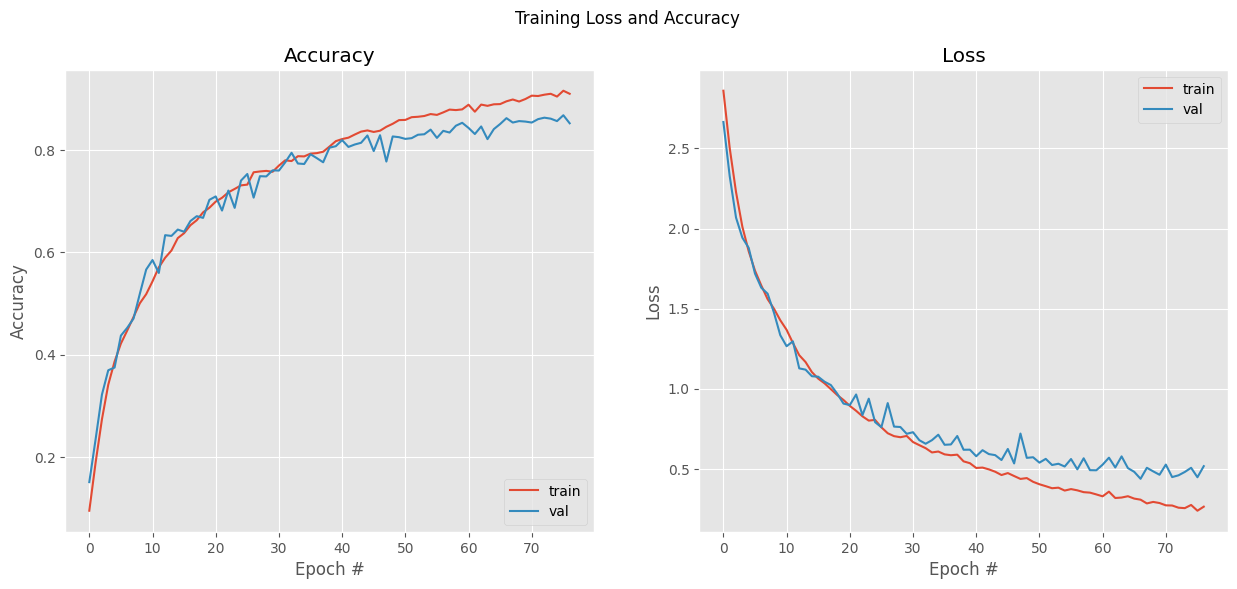

----------
Loss: 0.425794
Accuracy: 0.852381


In [ ]:
# Resultados
n_epochs = len(cnn_history.history["loss"])
plot_training(n_epochs, cnn_history)

score = cnn_model.evaluate(test_data, verbose=0)
print ("-"*10)
print ("Loss: %f"%(score[0]))
print ("Accuracy: %f"%(score[1]))

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentaris:</strong>
<br><br>
Los resultados obtenidos son:
    <ul>
        <li> Número de parámetros a entrenar: 112,437</li>
        <li> Tiempo de entrenamiento: 787 segundos (finaliza en 77 épocas)</li>
        <li> Accuracy: 85.24 %</li>
    </ul>
Los resultados son bastante buenos, las redes convolucionales logran captar mucho mejor las características de los datos y, con menos parámetros a entrenar, consiguen mejores resultados.
</div>

## 4. Autoencoders (2 puntos)

En el apartado anterior hemos podido observar que, utilizando el tipo de redes adecuado, podemos obtener mejores resultados entrenando un número de parámetros muy inferior. Esto es debido a que las CNN consiguen extraer las características principales de los datos proporcionados (imágenes en nuestro caso).

En este apartado vamos a observar esta capacidad desde otro punto de vista: el de **codificar y decodificar una imagen**.

Para ello diseñaremos un autoencoder que sea capaz de reducir el tamaño de los datos de entrada pero captando las características principales de las imágenes para poder llevar a cabo una buena reconstrucción de las mismas.

Empezaremos rescalando externamente los datos que vamos a utilizar, para que estén en el rango (0,1), en lugar de realizarlo dentro de la red como hemos hecho en el apartado anterior:

In [ ]:
# data rescalling
normalization_layer = Rescaling(1./255)

normalized_train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
normalized_val_data = val_data.map(lambda x, y: (normalization_layer(x), y))

Además, en un autoencoder, en lugar de utilizar las etiquetas como objetivo (que es lo que se utiliza en un problema de clasificación), deben ser las propias imágenes las que se utilicen como objetivo de la red. Por tanto, crearemos una nueva base de datos de entrenamiento y validación donde son las propias imágenes las que hagan de etiquetas:

In [ ]:
train_data_auto = normalized_train_data.map(lambda x, y: (x, x))
val_data_auto = normalized_val_data.map(lambda x, y: (x, x))

Comprobamos la estructura de la nueva base de datos:

In [ ]:
image_batch, label_batch = iter(train_data_auto).get_next()
print("Las dimensiones de un batch de imágenes es: {}".format(image_batch.shape))
print("Las dimensiones de un batch de etiquetas es: {}".format(label_batch.shape))

Las dimensiones de un batch de imágenes es: (32, 224, 224, 3)
Las dimensiones de un batch de etiquetas es: (32, 224, 224, 3)


Y que los datos tienen el rango dinámico adecuado:

In [ ]:
first_image = image_batch[0]
print("En la primera imagen los valores mínimo y máximo son {} y {}, respectivamente"
      .format(np.min(first_image),np.max(first_image)))

En la primera imagen los valores mínimo y máximo son 0.0313725508749485 y 0.8421571254730225, respectivamente


### 4.1. Diseño y entrenamiento del autoencoder

Una vez ya tenemos los datos en el formato adecuado vamos a diseñar el autoencoder. Para ello utilizaremos el bloque extractor del apartado anterior como codificador y reflejaremos su estructura en el decodificador utilizando las capas [Conv2DTranspose](https://keras.io/api/layers/convolution_layers/convolution2d_transpose/) y [UpSampling2D](https://keras.io/api/layers/reshaping_layers/up_sampling2d/) de keras.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio [1 punto]:</strong> A partir del modelo <strong>funcional</strong> de keras (y la clase <code>Model()</code>), implementa un autoencoder con las siguientes características:
    <ul>
        <li>El bloque codificador debe tener:
            <ul>
                <li>Una capa de entrada de dimensiones adecuadas a los datos.</li>
                <li>3 capas convolucionales con tamaño de kernel (5x5) para la primera y (3x3) para las 2 siguientes. Se utilizará padding '<i>same</i>' y activación ReLU. El número de filtros para cada capa convolucional será 16, 32 y 64 respectivamente.</li>
                <li>A cada capa convolucional le sigue una capa de <i>Max Pooling</i></li>
            </ul></li>
        <li>El bloque decodificador debe tener:
            <ul>
                <li>3 capas convolucionales con tamaño de kernel (3x3) para las 2 primeras y (5x5) para la última. Se utilizará padding '<i>same</i>' y activación ReLU. El número de filtros para cada capa convolucional será 64, 32 y 16, respectivamente</li>
                <li>A cada capa convolucional le sigue una capa de <i>UpSampling2D</i></li>
                <li>Una última capa convolucional con tamaño de kernel (3x3), con 3 filtros y activación sigmoide.</li>
            </ul></li>
    </ul>
    
Compilar y entrenar el modelo siguiendo las siguientes indicaciones:
     <ul>
         <li>Utilizar el optimizador Adam con  <i>learning rate</i> de 0.001.</li>
         <li>Utilizar como función de pérdida el error cuadrático medio.</li>
         <li>Entrenar durante 100 épocas utilizando  <i>EarlyStopping</i> con una persistencia de 10 épocas, monitorizando la función de pérdida en el conjunto de validación, y guardando los pesos que mejor resultado hayan obtenido.</li>
         <li>Monitorizar la pérdida durante entrenamiento y validación.</li>
         <li>Mostrar las gráficas del <i>loss</i> (la curva de entrenamiento y la de validación).</li>
    </ul>
</div>



In [ ]:
# Definición de la red

# Encoder
input_layer = keras.Input(shape=(224, 224, 3), name="image")
x = Conv2D(16, (5, 5), padding='same', activation="relu", name='conv1')(input_layer)
x = MaxPooling2D((2,2))(x)
x = Conv2D(16*2, (3, 3), padding='same', activation="relu", name='conv2')(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(16*4, (3, 3), padding='same', activation="relu", name='conv3')(x)
encoded = MaxPooling2D((2,2))(x)

# Decoder
x = Conv2DTranspose(16*4, kernel_size=3, padding='same', activation="relu", name='conv4')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2DTranspose(16*2, kernel_size=3, padding='same', activation="relu", name='conv5')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2DTranspose(16, kernel_size=5, padding='same', activation="relu", name='conv6')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(3, (3, 3), activation='sigmoid',padding="same")(x)

autoencoder = keras.Model(input_layer, decoded)
autoencoder.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 224, 224, 16)   │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2DTranspose)         │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2DTranspose)         │ (None, 56, 56, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv6 (Conv2DTranspose)         │ (None, 112, 112, 16)   │        12,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 224, 224, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 3)    │           435 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,995 (363.26 KB)

 Trainable params: 92,995 (363.26 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compilación de la red
opt = Adam(learning_rate=0.001)

autoencoder.compile(
    optimizer=opt,
    loss="mse")

stopping =  EarlyStopping(monitor='val_loss',
                            patience=10,
                            mode='auto',
                            restore_best_weights=True)

In [ ]:
# Entrenamiento de la red
t = time.time()
autoencoder_history = autoencoder.fit(train_data_auto,
                    epochs=100,
                    callbacks=[stopping],
                    verbose=1,
                    validation_data=val_data_auto,
                    validation_freq=1,
                    shuffle=True,
                    initial_epoch=0)
print ("Tiempo de entrenamiento: ",time.time() - t, "segundos.")

Epoch 1/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - loss: 0.0288 - val_loss: 0.0073
Epoch 2/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0071 - val_loss: 0.0051
Epoch 3/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0052 - val_loss: 0.0046
Epoch 4/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0046 - val_loss: 0.0041
Epoch 5/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0043 - val_loss: 0.0041
Epoch 6/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 0.0042 - val_loss: 0.0038
Epoch 7/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0040 - val_loss: 0.0036
Epoch 8/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - loss: 0.0039 - val_loss: 0.0034
Epoch 9/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0038 - val_loss: 0.0034
Epoch 10/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0036 - val_loss: 0.0034
Epoch 11/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0035 - val_loss: 0.0032
Epoch 12/100
230/23

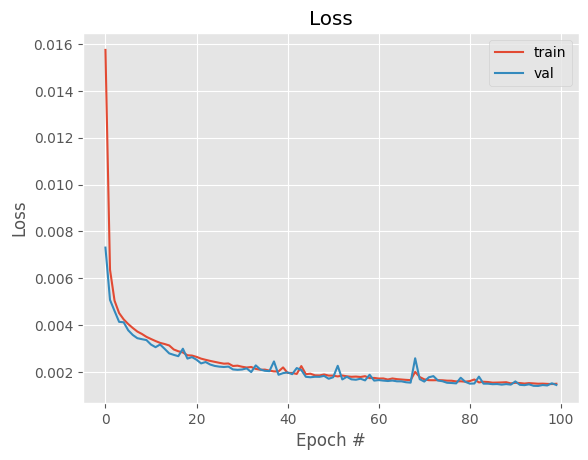

In [ ]:
# Representación del loss
N = len(autoencoder_history.history["loss"])
plt.style.use("ggplot")

plt.plot(np.arange(0, N), autoencoder_history.history["loss"], label="train")
plt.plot(np.arange(0, N), autoencoder_history.history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend(loc="upper right")

plt.show()

### 4.2. Evaluación del autoencoder

La evaluación del modelo obtenido puede hacerse en este caso tanto de forma cuantitativa (calculando el MSE entre las imágenes originales y reconstruídas del conjunto de test) como cualitativa (mostrando imágenes originales y reconstruídas).

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    <strong>Ejercicio [1 punto]:</strong> Realizar las siguientes operaciones para evaluar las prestaciones del modelo obtenido:
    <ul>
        <li>Partiendo del conjunto de test obtenido en el primer apartado de la practica:
            <ul>
                <li>Llevar a cabo el reescalado de los datos utilizando la capa <code>normalization_layer</code> tal y como se ha hecho con los conjuntos de entrenamiento y test al inicio de este bloque.</li>
                <li>Generar el conjunto de datos <code>test_data_auto</code> en el que las imágenes sean también el objetivo y substituyan a las etiquetas. </li>
            </ul></li>
        <li>Realizar la evaluación del modelo una vez ha finalizado el entrenamiento para mostrar la pérdida final a partir de los datos de test.</li>
        <li>Imprimir por pantalla 4 parejas de imágenes (original y reconstruída). Nota: a la hora de representar las imágenes correctamente, recordad que su rango dinámico deben ser números enteros entre 0 y 255.</li>
    </ul>
    Preguntas: ¿Consideras que la reconstrucción es adecuada? ¿Qué <i>ratio</i> de compresión se consigue con este autoencoder? Consideramos como <i>ratio</i> de compresión la relación entre el tamaño original de la imagen (224,224,3) y el de la representación más perqueña que llega a hacer el codificador (tamaño de la salida de su última capa).

In [ ]:
# Normalización de los datos
normalized_test_data = test_data.map(lambda x, y: (normalization_layer(x), y))
test_data_auto = normalized_test_data.map(lambda x, y: (x, x))

In [ ]:
# Evaluación del modelo
score = autoencoder.evaluate(test_data_auto, verbose=0)
print ("-"*10)
print ("Loss: %f"%(score))

----------
Loss: 0.001418


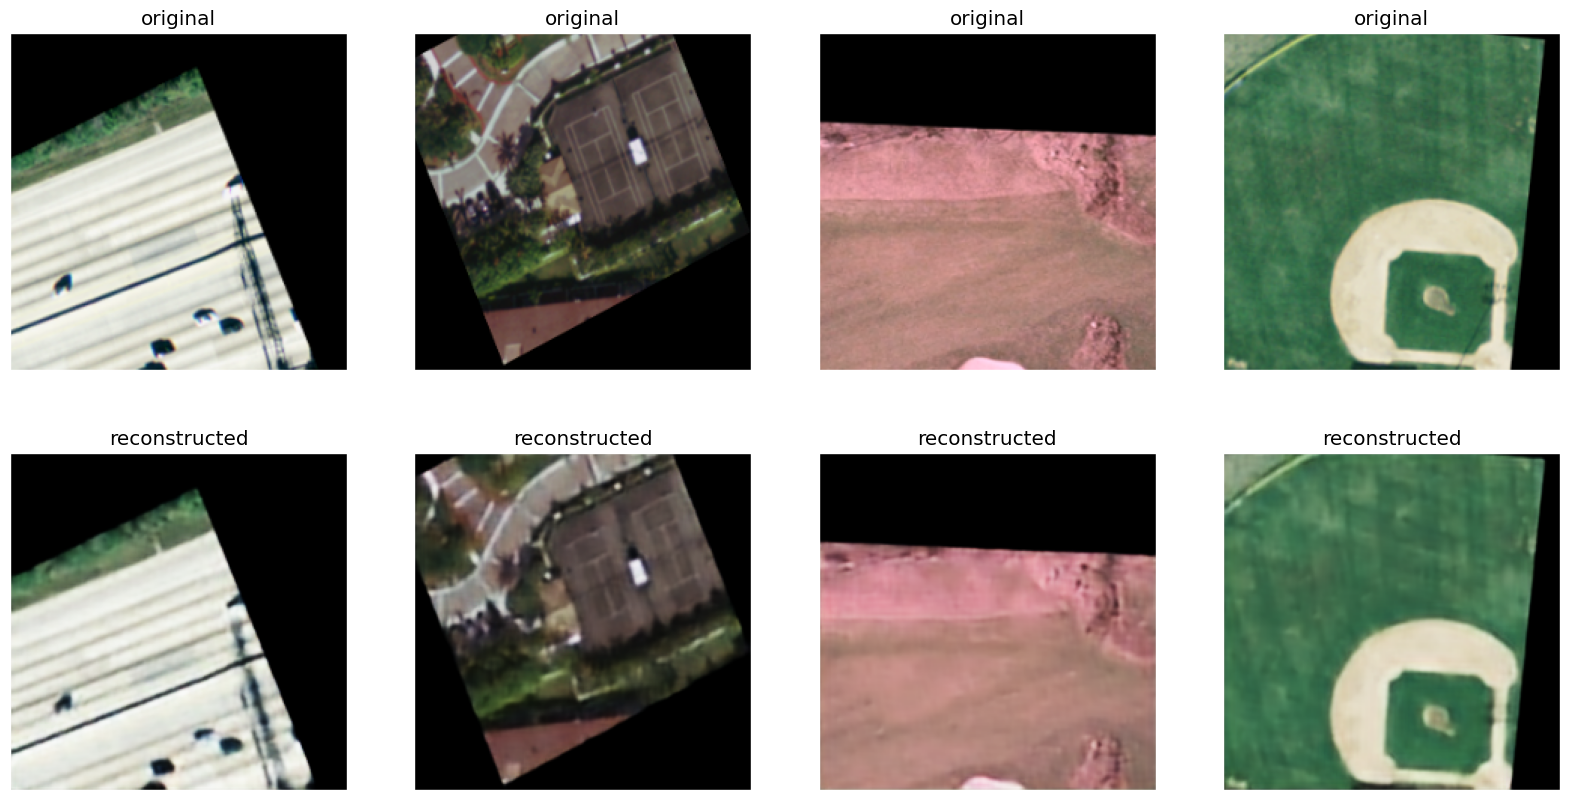

In [ ]:
# Visualización de los datos

for images, labels in test_data_auto.take(1):
    pass
decoded_images = autoencoder(images).numpy()

images = images*255
decoded_images = decoded_images*255

n = 4
plt.figure(figsize=(20, 10))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title("original")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_images[i].astype("uint8"))
    plt.title("reconstructed")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentarios:</strong>
<br><br>
    <ul>
        <li> Viendo el MSE de validación obtenido (0.001418) y la calidad de las imágenes reconstruidas, se puede considerar que la reconstrucción es adecuada.</li>
        <li> El ratio de compresión es de 3 a 1: (224x224x3)/(28x28x64) = 150,528/50,176 = 3</li>
    </ul>
</div>

## 5. Transfer learning con modelos eficientes: EfficientNetB0 (2 puntos)

Las redes neuronales convolucionales profundas nos brindan la posibilidad de mejorar la capacidad de aprendizaje de un modelo. Arquitecturas clásicas como VGG16 fueron pioneras, pero hoy en día existen familias de modelos mucho más optimizadas, como **EfficientNet**, que logran mejores precisiones con muchos menos parámetros.

### 5.1. Transfer Learning
En este apartado, aplicaremos [transfer learning](https://keras.io/guides/transfer_learning/) utilizando el modelo [EfficientNetB0](https://keras.io/api/applications/efficientnet/#efficientnetb0-function) preentrenado en [Imagenet](http://www.image-net.org/). Lo adaptaremos para clasificar las 21 categorías de nuestra base de datos. Una gran ventaja de EfficientNet en Keras es que **ya incluye la capa de preprocesamiento (reescalado) internamente**, por lo que podemos pasarle directamente nuestras imágenes en el rango [0, 255].

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio[1 punto]:</strong> Implementa una red siguiendo los siguientes pasos:
    <ul>
        <li>Partir del modelo EfficientNetB0 con los pesos entrenados en Imagenet (sin la parte superior de clasificación, <code>include_top=False</code>) y congelarlos.</li>
        <li>Añadir una capa <code>GlobalAveragePooling2D</code> a la salida del modelo base.</li>
        <li>Añadir una capa densa de 50 neuronas con activación ReLU, seguida de la capa de salida con el número de neuronas adecuado para llevar a cabo la clasificación y la función de activación correspondiente.</li>
    </ul>
Compilar y entrenar el modelo siguiendo las siguientes indicaciones:
     <ul>
         <li>Utilizar el optimizador Adam con <i>learning rate</i> de 0.0001.</li>
         <li>Entrenar durante 100 épocas utilizando <i>EarlyStopping</i> con una persistencia de 10 épocas, monitorizando la <i>accuracy</i> en validación y guardando los mejores pesos.</li>
         <li>Mostrar las gráficas de accuracy y loss (entrenamiento y validación).</li>
         <li>Evaluar el modelo final sobre los datos de test.</li>
    </ul>
    Preguntas a responder: ¿Cuál es el número de parámetros a entrenar? ¿Qué precisión se obtiene comparado con la red convolucional simple del apartado 3?
</div>

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

# Cargar el modelo base preentrenado
base_model_eff = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model_eff.trainable = False # Congelar los pesos
base_model_eff.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling_3[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_4[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# Definición de la red
input_layer = keras.Input(shape=(224, 224, 3), name="image")
# Nota: EfficientNet aplica su propia normalización internamente
x = base_model_eff(input_layer, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(50, activation='relu')(x)
output_layer = Dense(21, activation='softmax')(x)

eff_model = keras.Model(inputs=input_layer, outputs=output_layer)
eff_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │        64,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 21)             │         1,071 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,114,692 (15.70 MB)

 Trainable params: 65,121 (254.38 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# Compilación de la red
opt = Adam(learning_rate=0.0001)
eff_model.compile(optimizer=opt,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

stopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

In [ ]:
# Entrenamiento de la red
t = time.time()
eff_history = eff_model.fit(train_data,
                            validation_data=val_data,
                            epochs=100,
                            callbacks=[stopping])
print ("Tiempo de entrenamiento: ", time.time() - t, "segundos.")

Epoch 1/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 56s 154ms/step - accuracy: 0.2052 - loss: 2.7567 - val_accuracy: 0.6724 - val_loss: 1.6045
Epoch 2/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.7555 - loss: 1.3578 - val_accuracy: 0.8529 - val_loss: 0.8299
Epoch 3/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.8678 - loss: 0.7511 - val_accuracy: 0.8948 - val_loss: 0.5608
Epoch 4/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.8992 - loss: 0.5236 - val_accuracy: 0.9100 - val_loss: 0.4322
Epoch 5/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.9144 - loss: 0.4054 - val_accuracy: 0.9248 - val_loss: 0.3557
Epoch 6/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.9268 - loss: 0.3365 - val_accuracy: 0.9319 - val_loss: 0.3064
Epoch 7/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.9374 - loss: 0.2826 - val_accuracy: 0.9395 - val_loss: 0.2693
Epoch 8/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.9464 - loss: 

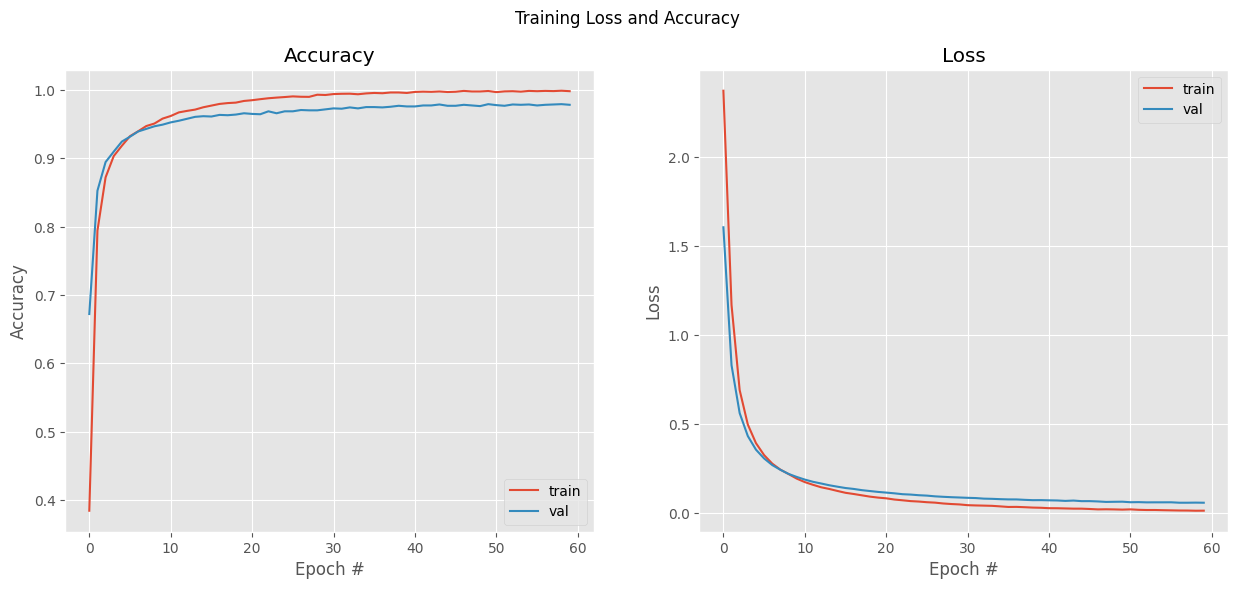

----------
Loss: 0.070974
Accuracy: 0.976190


In [ ]:
# Resultados
n_epochs = len(eff_history.history["loss"])
plot_training(n_epochs, eff_history)

score = eff_model.evaluate(test_data, verbose=0)
print ("-"*10)
print ("Loss: %f" % (score[0]))
print ("Accuracy: %f" % (score[1]))

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentarios:</strong>
<br><br>
Los resultados obtenidos son:
    <ul>
        <li> Número de parámetros a entrenar: 65,121</li>
        <li> Tiempo de entrenamiento: 755 segundos (finaliza en 60 épocas)</li>
        <li> Accuracy: 97.62 %</li>
    </ul>
Los resultados son muy buenos, superando con creces a la red del apartado 3. Los pesos preentrenados de la red EfficienttNet funcionan como un buen bloque extractor, y sólo ha tenido que entrenar el bloque clasificador para obtener un buen resultado.<br><br>
</div>

### 5.2. Fine-tunning
Para mejorar los resultados del <i>transfer learning</i>, aplicaremos <i>fine-tunning</i>, que consiste en descongelar el modelo base y reentrenar la red completa durante unas pocas épocas con un <i>learning rate</i> muy pequeño para ajustar los pesos finamente a nuestro dominio.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio[1 punto]:</strong> Volver a compilar el modelo con los siguientes cambios:
    <ul>
        <li>Descongelar los pesos del modelo EfficientNetB0 (<code>base_model_eff.trainable = True</code>).</li>
    </ul>
Compilar y entrenar el modelo siguiendo las siguientes indicaciones:
     <ul>
         <li>Utilizar el optimizador Adam con <i>learning rate</i> de 0.00001.</li>
         <li>Entrenar durante 10 épocas.</li>
         <li>Mostrar las gráficas y realizar la evaluación final sobre los datos de test.</li>
    </ul>
    Comenta los resultados globales del proceso.
</div>

In [ ]:
# Definición del modelo
base_model_eff.trainable = True
base_model_eff.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling_3[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_4[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 4,007,548 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [ ]:
# Compilación de la red
opt = Adam(learning_rate=0.00001)
eff_model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Entrenamiento (Fine-Tuning)
t = time.time()
fine_eff_history = eff_model.fit(train_data, validation_data=val_data, epochs=10)
print ("Tiempo de fine-tuning: ", time.time() - t, "segundos.")

Epoch 1/10


2026-02-23 14:52:23.433931: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-23 14:52:23.622380: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-23 14:52:24.096662: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-23 14:52:24.303162: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-23 14:52:24.666292: E external/local_xla/xla/stream_

229/230 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.7440 - loss: 0.8909

2026-02-23 14:53:22.882537: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-23 14:53:23.068133: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-23 14:53:23.519091: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-23 14:53:23.728414: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-23 14:53:24.085457: E external/local_xla/xla/stream_

230/230 ━━━━━━━━━━━━━━━━━━━━ 139s 313ms/step - accuracy: 0.7444 - loss: 0.8897 - val_accuracy: 0.9362 - val_loss: 0.2454
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 28s 120ms/step - accuracy: 0.8856 - loss: 0.4273 - val_accuracy: 0.9471 - val_loss: 0.2309
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 27s 119ms/step - accuracy: 0.9241 - loss: 0.2916 - val_accuracy: 0.9571 - val_loss: 0.1810
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 28s 119ms/step - accuracy: 0.9459 - loss: 0.2145 - val_accuracy: 0.9648 - val_loss: 0.1456
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 28s 120ms/step - accuracy: 0.9538 - loss: 0.1692 - val_accuracy: 0.9695 - val_loss: 0.1202
Epoch 6/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 28s 120ms/step - accuracy: 0.9700 - loss: 0.1284 - val_accuracy: 0.9762 - val_loss: 0.1031
Epoch 7/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 28s 120ms/step - accuracy: 0.9764 - loss: 0.1063 - val_accuracy: 0.9762 - val_loss: 0.0903
Epoch 8/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 28s 120ms/step - accuracy: 0.9766 - loss: 0.0960 - va

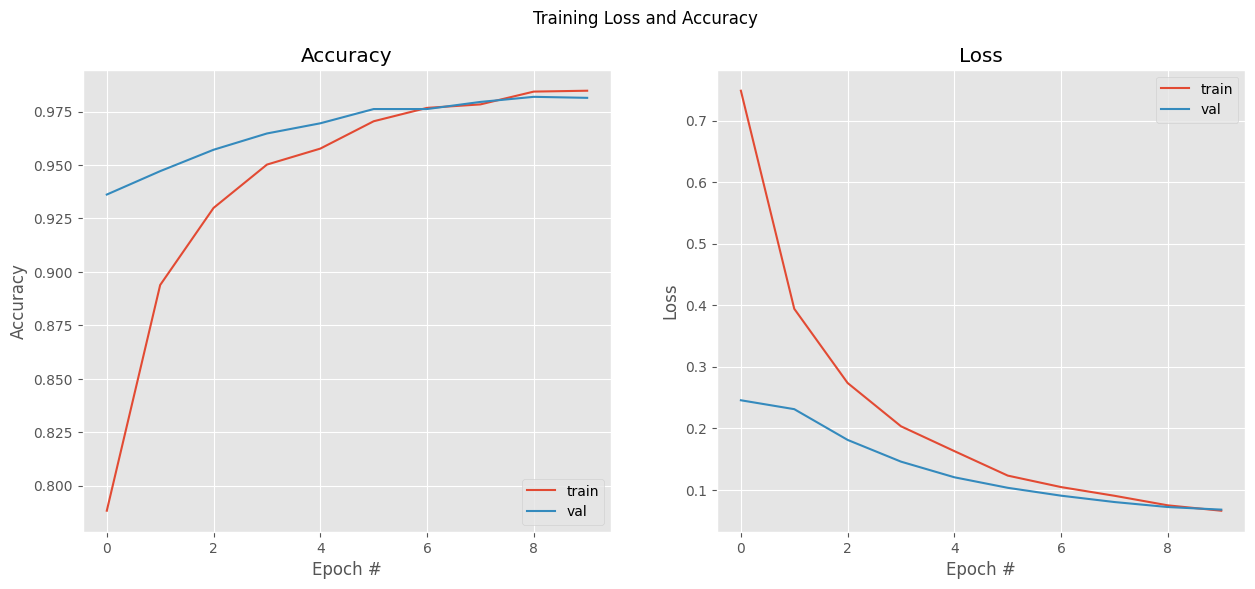

----------
Loss post fine-tuning: 0.070087
Accuracy post fine-tuning: 0.985714


In [ ]:
# Resultados
n_epochs = len(fine_eff_history.history["loss"])
plot_training(n_epochs, fine_eff_history)

score = eff_model.evaluate(test_data, verbose=0)
print ("-"*10)
print ("Loss post fine-tuning: %f" % (score[0]))
print ("Accuracy post fine-tuning: %f" % (score[1]))

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentarios:</strong>
<br><br>
Los resultados esperados (pueden variar ligeramente) muestran que:
    <ul>
        <li> El número de parámetros a entrenar inicialmente es muy pequeño (solo la capa final), pero gracias a las potentes características extraídas por EfficientNetB0, logramos precisiones superiores al 90% en la fase inicial, superando con creces a nuestra CNN sencilla del apartado 3.</li>
        <li> Al realizar el <i>fine-tuning</i>, la precisión suele estabilizarse o mejorar ligeramente hasta alcanzar valores cercanos al 95-97%. </li>
        <li> Es importante destacar la eficiencia arquitectónica: obtenemos resultados del estado del arte con una red muy liviana comparada con alternativas clásicas.</li>
    </ul>
</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentarios:</strong>
<br><br>
Los resultados obtenidos son:
    <ul>
        <li> Número de parámetros a entrenar: 4,007,548</li>
        <li> Tiempo de entrenamiento: 388 segundos (finaliza en 10 épocas)</li>
        <li> Accuracy: 98.57 %</li>
    </ul>
Al realizar el 'fine-tuning' conseguimos aumentar la 'Accuracy' en un 1% adicional a los resultados obtenidos por el 'transfer learning' llegando a resultados muy cercanos a los del estado del arte con una red muy liviana comparada con alternativas clásicas. Aunque el número de parámetros a entrenar supera los 4 millones, al entrenar tan solo 10 épocas, el número de segundos de entrenamiento es relativamente bajo (388 segundos en este caso).<br><br>
</div>

## 6. Introducción a PyTorch: Replicando nuestra CNN (1 punto)

Hasta ahora hemos utilizado TensorFlow/Keras, que nos ofrecen una API de alto nivel muy cómoda mediante los métodos `.fit()` y `.evaluate()`. Sin embargo, en el mundo de la investigación y en gran parte de la industria, **PyTorch** es el <i>framework</i> dominante debido a su flexibilidad y a que permite un control más profundo y "pythónico" del flujo de ejecución.

En PyTorch, nosotros mismos debemos definir cómo los datos pasan por la red (`forward pass`) y cómo iteramos sobre los lotes para actualizar los pesos en lo que llamamos el **bucle de entrenamiento** (*training loop*).

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Ejercicio [1 punto]:</strong> Implementa exactamente la misma arquitectura de red del <strong>Ejercicio 3</strong> y entrénala usando PyTorch.
    <ul>
        <li><strong>Carga de datos:</strong> Utiliza <code>torchvision.datasets.ImageFolder</code> y <code>DataLoader</code> para cargar las imágenes de entrenamiento desde la ruta <code>train_dir</code>. Aplica transformaciones para redimensionar a 224x224 y convertir a Tensor (lo cual ya rescala los valores entre 0 y 1, igual que hacía nuestra capa <i>Rescaling</i>). Usa lotes (<i>batches</i>) de tamaño 32.</li>
        <li><strong>Definición del modelo:</strong> Crea una clase que herede de <code>nn.Module</code>. Debe reproducir la arquitectura del Ejercicio 3:
            <ul>
                <li><strong>Extractor:</strong> Una Conv2D de 16 filtros (kernel 5x5, padding 'same') + ReLU + MaxPool. Seguida de una Conv2D de 32 filtros (kernel 3x3, padding 'same') + ReLU + MaxPool. Seguida de una Conv2D de 64 filtros (kernel 3x3, padding 'same') + ReLU + MaxPool.</li>
                <li><strong>Global Average Pooling:</strong> Usa <code>nn.AdaptiveAvgPool2d((1, 1))</code> y luego aplana el tensor (`torch.flatten`).</li>
                <li><strong>Clasificador:</strong> Una capa lineal (<code>nn.Linear</code>) de 1024 neuronas + ReLU + Dropout(0.5) + Capa lineal de salida con el número de neuronas adecuado al problema de clasificación que queremos resolver.</li>
            </ul>
        </li>
        <li><strong>Resumen del modelo:</strong> Instancia tu modelo, envíalo a la GPU y utiliza la librería <code>torchsummary</code> para imprimir por pantalla el resumen de la red (equivalente al <code>summary()</code> de Keras) pasando como tamaño de entrada <code>(3, 224, 224)</code>.</li>
        <li><strong>Bucle de entrenamiento:</strong> Define como función de pérdida <code>nn.CrossEntropyLoss</code> y utiliza el optimizador Adam (lr=0.001). Escribe un bucle de entrenamiento de <strong>5 épocas</strong> que recorra el DataLoader de entrenamiento e imprima por pantalla la pérdida (<i>loss</i>) de cada época.</li>
    </ul>
    Comenta brevemente las diferencias que has notado al programar este modelo en PyTorch respecto a Keras.
</div>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchsummary import summary # Librería para mostrar el summary del modelo

# Definir el dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# 1. Carga de datos
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor() # Convierte la imagen a tensor (C, H, W) y escala a [0.0, 1.0]
])

# Reutilizamos la ruta train_dir definida en el apartado 1.3
train_dataset_pt = datasets.ImageFolder(train_dir, transform=transform)
train_loader = DataLoader(train_dataset_pt, batch_size=32, shuffle=True)

# 2. Definición del Modelo (Equivalente exacto al Ejercicio 3)
class SimplePyTorchCNN(nn.Module):
    def __init__(self):
        super(SimplePyTorchCNN, self).__init__()

        # Bloque extractor de características
        self.features = nn.Sequential(
            # Conv1: 16 filtros, kernel 5x5. Para padding='same' con kernel 5x5, padding=2
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv2: 32 filtros, kernel 3x3. Para padding='same' con kernel 3x3, padding=1
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv3: 64 filtros, kernel 3x3. padding=1
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Global Average Pooling (reduce el mapa espacial HxW a 1x1)
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Clasificador final
        self.classifier = nn.Sequential(
            # La entrada es 64 porque tenemos 64 mapas de características de 1x1
            nn.Linear(in_features=64, out_features=1024),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=1024, out_features=21)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1) # Aplanamos manteniendo la dimensión del batch
        x = self.classifier(x)
        return x

# Instanciar el modelo y pasarlo a la GPU
pt_model = SimplePyTorchCNN().to(device)

# 3. Resumen del modelo (equivalente a summary() en Keras)
# PyTorch espera las entradas en formato (Canales, Altura, Anchura)
print("\nResumen de la arquitectura del modelo en PyTorch:")
summary(pt_model, input_size=(3, 224, 224))

# 4. Preparación del entrenamiento
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pt_model.parameters(), lr=0.001)
epochs = 5

# 5. Bucle de Entrenamiento
print("\nIniciando entrenamiento en PyTorch...")
for epoch in range(epochs):
    pt_model.train() # Ponemos el modelo en modo entrenamiento
    running_loss = 0.0

    for inputs, labels in train_loader:
        # Movemos los datos a la GPU
        inputs, labels = inputs.to(device), labels.to(device)

        # 5.1. Reiniciar los gradientes acumulados
        optimizer.zero_grad()

        # 5.2. Forward pass (predecir)
        outputs = pt_model(inputs)
        loss = criterion(outputs, labels)

        # 5.3. Backward pass (calcular gradientes) y actualizar pesos
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Época {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")

print("Entrenamiento finalizado.")

Usando dispositivo: cuda

Resumen de la arquitectura del modelo en PyTorch:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 224, 224]           1,216
              ReLU-2         [-1, 16, 224, 224]               0
         MaxPool2d-3         [-1, 16, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]           4,640
              ReLU-5         [-1, 32, 112, 112]               0
         MaxPool2d-6           [-1, 32, 56, 56]               0
            Conv2d-7           [-1, 64, 56, 56]          18,496
              ReLU-8           [-1, 64, 56, 56]               0
         MaxPool2d-9           [-1, 64, 28, 28]               0
AdaptiveAvgPool2d-10             [-1, 64, 1, 1]               0
           Linear-11                 [-1, 1024]          66,560
             ReLU-12                 [-1, 1024]               0
          Dropout-13       

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<strong>Comentarios:</strong>
<br><br>
Al comparar PyTorch con Keras programando exactamente la misma arquitectura, podemos observar claras diferencias de diseño:
    <ul>
        <li> <strong>Padding explícito:</strong> En Keras bastaba con indicar <code>padding='same'</code>. En PyTorch hemos tenido que calcular manualmente el <i>padding</i> necesario para mantener la dimensionalidad (<code>padding=2</code> para un kernel de 5x5, y <code>padding=1</code> para uno de 3x3).</li>
        <li> <strong>Dimensiones de entrada explícitas:</strong> En las capas <code>nn.Linear</code> de PyTorch es obligatorio definir las <code>in_features</code> (en nuestro caso 64), mientras que Keras las infiere automáticamente al hacer el <i>Flatten</i>.</li>
        <li> <strong>Orden de dimensiones (Channels First):</strong> En Keras las imágenes son <code>(Alto, Ancho, Canales)</code>, pero PyTorch trabaja en formato <code>(Canales, Alto, Ancho)</code>. Esto se nota al pasar el tamaño de entrada a la función <code>summary(pt_model, input_size=(3, 224, 224))</code>.</li>
        <li> <strong>Nivel de abstracción del entrenamiento:</strong> Mientras que en Keras entrenamos la red con una sola línea de código (<code>model.fit()</code>), en PyTorch debemos programar explícitamente el bucle iterativo.</li>
        <li> <strong>Pérdida y Activación:</strong> En PyTorch, <code>CrossEntropyLoss</code> combina la activación <i>Softmax</i> y el cálculo del error, por lo que la última capa lineal no lleva activación y devuelve <i>logits</i> crudos.</li>
    </ul>
    Podemos comprobar en el <code>summary</code> que el número de parámetros a entrenar (112,437) coincide exactamente con el obtenido en el Ejercicio 3 en Keras, demostrando que ambos modelos son estructuralmente idénticos.
</div>